<a href="https://colab.research.google.com/github/salsilsulselsol/Data-Scientist-Supervisor-Nasional-Experiment/blob/main/02_Data_Objects_and_Selection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 2: Data Objects, Selection, and Sampling

**Objective:**
Perform comprehensive data understanding, quality verification, statistical exploration, sampling, and integration using the Breast Cancer dataset.

**Dataset Context:**

Breast Cancer Wisconsin (Diagnostic) Dataset.

Target: 0 (Malignant), 1 (Benign).

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Configure visualization aesthetic
sns.set_theme(style="whitegrid")

# Load the dataset
cancer_data = load_breast_cancer()
df = pd.DataFrame(data=cancer_data.data, columns=cancer_data.feature_names)
df['target'] = cancer_data.target

print("Dataset loaded successfully.")

Dataset loaded successfully.


## 1. Data Understanding (Attributes and Records)

**Goal:**
Identify the entities, measurement attributes (continuous data), and records (instances) within the dataset.

In [2]:
print("--- 1. DATASET DIMENSIONS ---")
# View total records (rows) and attributes (columns)
records, attributes = df.shape
print(f"Total Records (Rows): {records}")
print(f"Total Attributes (Columns): {attributes}")

--- 1. DATASET DIMENSIONS ---
Total Records (Rows): 569
Total Attributes (Columns): 31


In [3]:
print("--- 2. ATTRIBUTE DATA TYPES ---")
# Check data types across all features
print(df.dtypes.value_counts())

--- 2. ATTRIBUTE DATA TYPES ---
float64    30
int64       1
Name: count, dtype: int64


In [4]:
print("--- 3. FIRST 5 RECORDS ---")
# View the top records of the dataset to understand the structure
df.head()

--- 3. FIRST 5 RECORDS ---


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [5]:
print("--- 4. TARGET CLASS DISTRIBUTION ---")
# Check the distribution percentage of the target classes
print(df['target'].value_counts(normalize=True) * 100)

--- 4. TARGET CLASS DISTRIBUTION ---
target
1    62.741652
0    37.258348
Name: proportion, dtype: float64


## 2. Exploratory Data Analysis (EDA)

**Goal:**
Visualize data distributions and relationships between attributes (correlation) to support feature selection decisions.

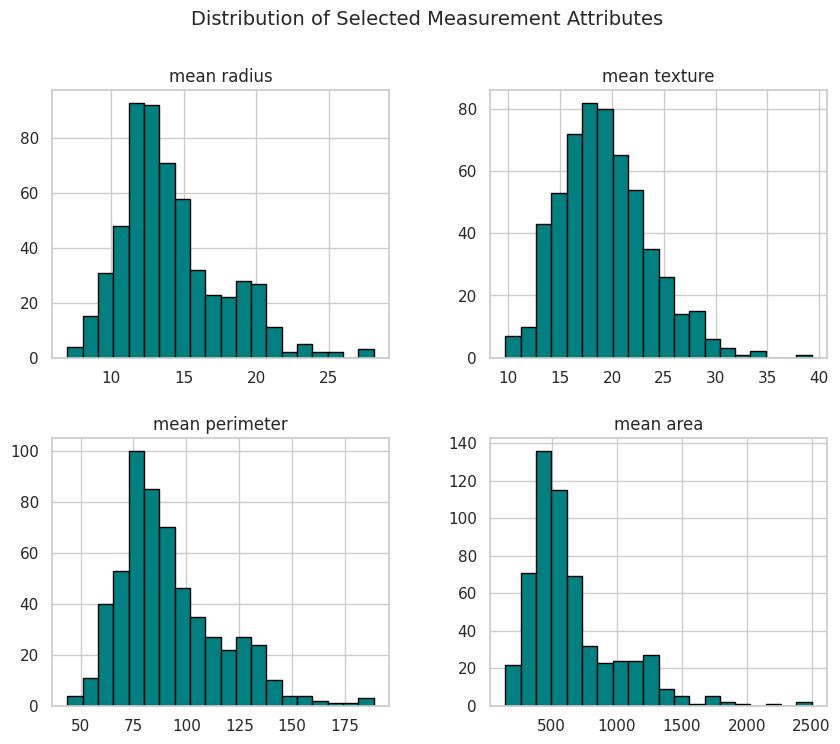

In [6]:
# 1. Feature Distributions (Histograms)
features_to_plot = ['mean radius', 'mean texture', 'mean perimeter', 'mean area']

df[features_to_plot].hist(figsize=(10, 8), bins=20, color='teal', edgecolor='black')
plt.suptitle('Distribution of Selected Measurement Attributes', fontsize=14)
plt.show()

/tmp/ipykernel_946/2288771586.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y='mean radius', data=df, palette='Set2')


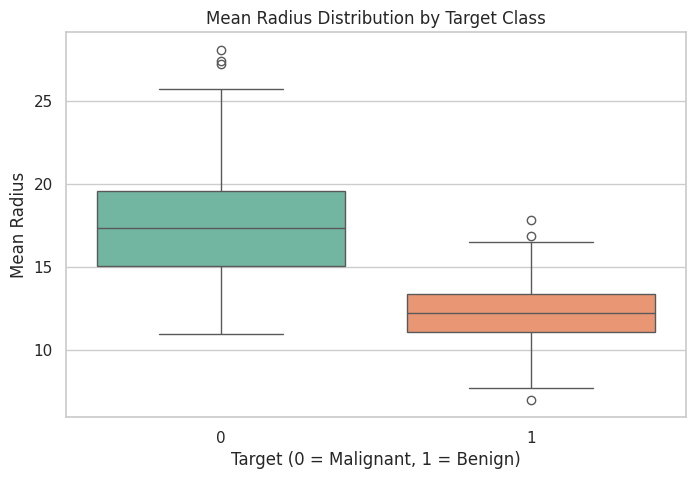

In [7]:
# 2. Attribute Distribution by Target Class (Boxplot)
plt.figure(figsize=(8, 5))
sns.boxplot(x='target', y='mean radius', data=df, palette='Set2')
plt.title('Mean Radius Distribution by Target Class')
plt.xlabel('Target (0 = Malignant, 1 = Benign)')
plt.ylabel('Mean Radius')
plt.show()

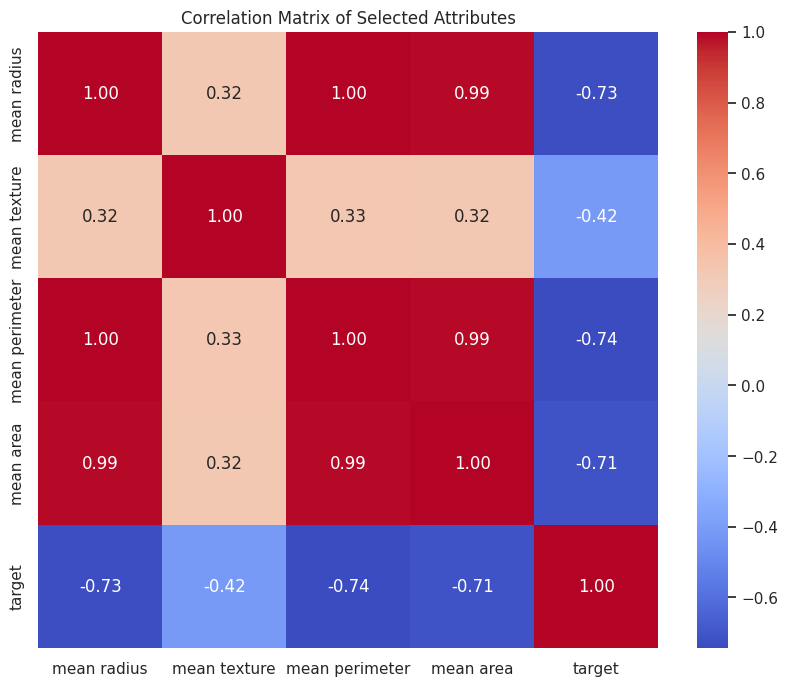

In [8]:
# 3. Multivariate Correlation (Heatmap)
plt.figure(figsize=(10, 8))
subset_cols = features_to_plot + ['target']
correlation_matrix = df[subset_cols].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Selected Attributes')
plt.show()

## 3. Data Quality Verification

**Goal:**
Ensure accuracy, completeness, and consistency by checking for missing values, duplicates, and statistical outliers.

In [9]:
print("--- 1. COMPLETENESS CHECK ---")
# Check for any missing values in the dataset
missing_values = df.isnull().sum().sum()
print(f"Total Missing Values: {missing_values}")

--- 1. COMPLETENESS CHECK ---
Total Missing Values: 0


In [10]:
print("--- 2. CONSISTENCY CHECK ---")
# Check for exact duplicate rows
duplicate_rows = df.duplicated().sum()
print(f"Total Duplicate Records: {duplicate_rows}")

--- 2. CONSISTENCY CHECK ---
Total Duplicate Records: 0


In [11]:
print("--- 3. OUTLIER DETECTION (IQR METHOD) ---")
# Detect outliers for selected features
outlier_summary = {}
for col in features_to_plot:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
    outlier_summary[col] = outliers

print("Outliers Detected per Attribute:")
for feature, count in outlier_summary.items():
    print(f"- {feature}: {count} records")

--- 3. OUTLIER DETECTION (IQR METHOD) ---
Outliers Detected per Attribute:
- mean radius: 14 records
- mean texture: 7 records
- mean perimeter: 13 records
- mean area: 25 records


## 4. Data Selection and Sampling

**Goal:**
Apply Probability Sampling (Stratified Sampling) to split the dataset while maintaining the original proportion of the target classes.

In [12]:
print("--- STRATIFIED SAMPLING ---")
# Separate features (X) and target (y)
X = df.drop('target', axis=1)
y = df['target']

# Perform Stratified Sampling (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print(f"Original Target Distribution:\n{y.value_counts(normalize=True)}\n")
print(f"Training Target Distribution:\n{y_train.value_counts(normalize=True)}\n")
print(f"Testing Target Distribution:\n{y_test.value_counts(normalize=True)}")

--- STRATIFIED SAMPLING ---
Original Target Distribution:
target
1    0.627417
0    0.372583
Name: proportion, dtype: float64

Training Target Distribution:
target
1    0.626374
0    0.373626
Name: proportion, dtype: float64

Testing Target Distribution:
target
1    0.631579
0    0.368421
Name: proportion, dtype: float64


## 5. Data Integration and Formatting

**Goal:**
Standardize naming conventions and scale numerical features to prepare the dataset for machine learning algorithms.

In [13]:
print("--- 1. STANDARDIZE ATTRIBUTE NAMES ---")
# Replace spaces with underscores in attribute names
df.columns = [col.replace(' ', '_') for col in df.columns]

print("Updated Attribute Names (First 5):")
print(df.columns[:5].tolist())

--- 1. STANDARDIZE ATTRIBUTE NAMES ---
Updated Attribute Names (First 5):
['mean_radius', 'mean_texture', 'mean_perimeter', 'mean_area', 'mean_smoothness']


In [14]:
print("--- 2. DATA SCALING ---")
# Initialize Standard Scaler
scaler = StandardScaler()

X_formatted = df.drop('target', axis=1)
y_formatted = df['target']

# Split again with the properly formatted data names
X_train_fmt, X_test_fmt, y_train_fmt, y_test_fmt = train_test_split(
    X_formatted, y_formatted, test_size=0.2, stratify=y_formatted, random_state=42
)

# Fit scaler on training data ONLY, then transform both train and test
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_fmt), columns=X_train_fmt.columns)

print("Training Data After Standardization (Mean ~ 0, Std ~ 1):")
X_train_scaled.iloc[:, :4].head()

--- 2. DATA SCALING ---
Training Data After Standardization (Mean ~ 0, Std ~ 1):


,mean_radius,mean_texture,mean_perimeter,mean_area
0,-1.072001,-0.658425,-1.088080,-0.939274
1,1.748743,0.066502,1.751157,1.745559
2,-0.974734,-0.931124,-0.997709,-0.867589
3,-0.145103,-1.215186,-0.123013,-0.253192
4,-0.771617,-0.081211,-0.803700,-0.732927
